# UK Retail Sales: Exploratory Data Analysis

This notebook explores monthly UK retail sales trends using the cleaned core dataset produced in the data-audit notebook.

## Objectives

- Examine long-term changes in retail sales value and volume.
- Compare nominal sales growth with real sales-volume growth.
- Investigate retail price movements using the implied deflator.
- Identify unusual periods and major economic disruptions.
- Prepare findings and visualisations for the final Tableau dashboard.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
data_path = Path("data") / "processed" / "retail_sales_core_monthly.csv"

retail = pd.read_csv(data_path, parse_dates=["date"])

print("File found:", data_path.exists())
print("Dataset shape:", retail.shape)
retail.head()

File found: True
Dataset shape: (356, 6)


,date,value_yoy_pct,value_mom_pct,volume_yoy_pct,volume_mom_pct,implied_deflator_yoy_pct
0,1997-01-01,6.2,1.9,4.5,1.6,2.3
1,1997-02-01,4.6,0.8,3.1,0.8,1.9
2,1997-03-01,5.3,1.2,3.7,1.0,1.4
3,1997-04-01,3.9,0.1,3.0,0.5,1.2
4,1997-05-01,4.4,-0.1,3.2,-0.3,1.1


## 1. Dataset overview

Before analysing trends, we confirm the dataset structure, date coverage, data types and completeness.

In [4]:
print("Rows:", len(retail))
print("Columns:", retail.shape[1])
print("Start date:", retail["date"].min())
print("End date:", retail["date"].max())
print("\nData types:")
print(retail.dtypes)

Rows: 356
Columns: 6
Start date: 1997-01-01 00:00:00
End date: 2026-08-01 00:00:00

Data types:
date                        datetime64[us]
value_yoy_pct                      float64
value_mom_pct                      float64
volume_yoy_pct                     float64
volume_mom_pct                     float64
implied_deflator_yoy_pct           float64
dtype: object


In [5]:
print("Missing values:")
print(retail.isna().sum())

print("\nDuplicated dates:", retail["date"].duplicated().sum())

Missing values:
date                        0
value_yoy_pct               0
value_mom_pct               0
volume_yoy_pct              0
volume_mom_pct              0
implied_deflator_yoy_pct    0
dtype: int64

Duplicated dates: 0


### Data-quality finding

The processed dataset contains 356 unique and complete monthly observations from January 1997 to August 2026. All variables have the correct data type, with no missing values or duplicated dates. The dataset is therefore ready for exploratory time-series analysis.

## 2. Descriptive statistics

We first summarise the typical growth rates, variability and extreme values across the complete study period.

In [6]:
summary_stats = (
    retail.drop(columns="date")
    .describe()
    .T
    .round(2)
)

summary_stats

,count,mean,std,min,25%,50%,75%,max
value_yoy_pct,356.0,3.46,3.81,-24.0,2.20,3.5,4.62,43.5
value_mom_pct,356.0,0.31,1.91,-18.9,-0.30,0.3,0.90,13.2
volume_yoy_pct,356.0,1.90,4.20,-23.0,0.20,1.9,3.70,41.0
volume_mom_pct,356.0,0.18,1.86,-17.8,-0.43,0.2,0.72,13.2
implied_deflator_yoy_pct,356.0,1.60,3.04,-5.1,0.10,1.2,2.80,13.0


### Initial statistical findings

Across the complete period, retail sales value increased by an average of 3.46% per year, compared with average sales-volume growth of 1.90%. The implied retail-price deflator averaged 1.60%.

The approximate relationship between these measures is economically intuitive: nominal value growth reflects changes in both the quantity purchased and retail prices.

The unusually large minimum and maximum growth rates suggest that exceptional economic periods—particularly the COVID-19 disruption and subsequent recovery—should be investigated separately.

## 3. Long-term retail sales growth

We compare year-on-year growth in sales value with growth in sales volume. This distinguishes changes in the amount spent from changes in the quantity of goods purchased.

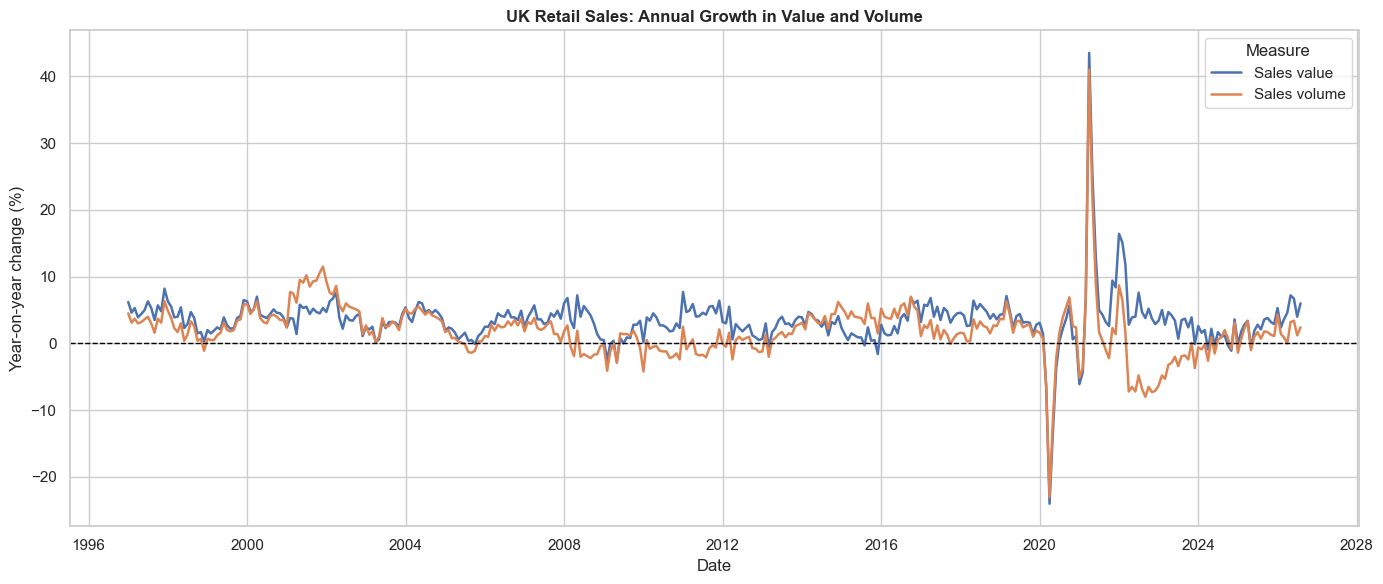

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=retail,
    x="date",
    y="value_yoy_pct",
    label="Sales value",
    linewidth=1.8,
    ax=ax
)

sns.lineplot(
    data=retail,
    x="date",
    y="volume_yoy_pct",
    label="Sales volume",
    linewidth=1.8,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("UK Retail Sales: Annual Growth in Value and Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year change (%)")
ax.legend(title="Measure")

plt.tight_layout()
plt.show()

### Value-versus-volume finding

Retail sales value and volume generally followed similar movements before 2020, although value growth was usually higher because it also incorporated changes in retail prices.

COVID-19 produced an exceptional fall and rebound in both measures during 2020 and 2021. A particularly important divergence then emerged during 2022 and 2023: nominal sales value continued to grow while real sales volume contracted. This indicates that consumers were spending more money primarily because prices had risen, despite purchasing fewer goods.

More recently, volume growth has recovered, although it generally remains below value growth.

## 4. Retail price growth

The implied deflator measures the difference between changes in sales value and sales volume. It therefore provides an indicator of how retail prices have changed over time.

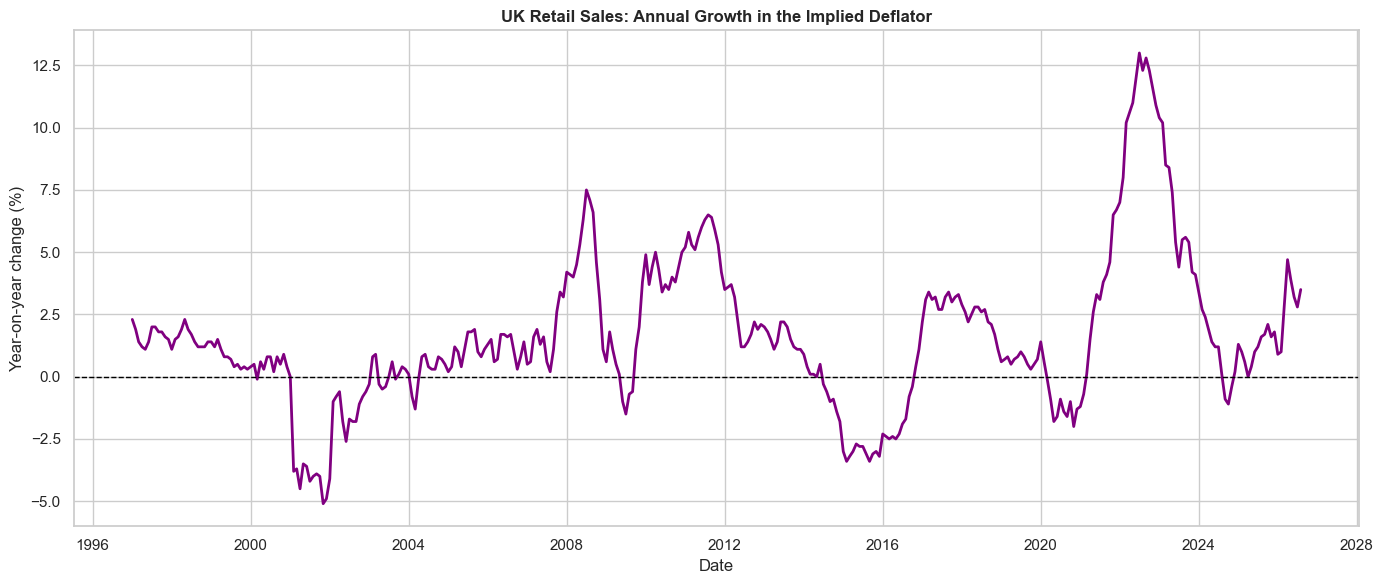

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=retail,
    x="date",
    y="implied_deflator_yoy_pct",
    color="purple",
    linewidth=2,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("UK Retail Sales: Annual Growth in the Implied Deflator")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year change (%)")

plt.tight_layout()
plt.show()

In [9]:
highest_deflator = retail.loc[
    retail["implied_deflator_yoy_pct"].idxmax(),
    ["date", "implied_deflator_yoy_pct"]
]

lowest_deflator = retail.loc[
    retail["implied_deflator_yoy_pct"].idxmin(),
    ["date", "implied_deflator_yoy_pct"]
]

print("Highest deflator growth:")
print(highest_deflator)

print("\nLowest deflator growth:")
print(lowest_deflator)

Highest deflator growth:
date                        2022-07-01 00:00:00
implied_deflator_yoy_pct                   13.0
Name: 306, dtype: object

Lowest deflator growth:
date                        2001-11-01 00:00:00
implied_deflator_yoy_pct                   -5.1
Name: 58, dtype: object


### Retail-price finding

The implied deflator reached its highest annual growth rate of 13.0% in July 2022. This helps explain why retail sales value remained comparatively strong while the volume of goods purchased declined during the cost-of-living crisis.

The lowest rate was −5.1% in November 2001, indicating a period of retail-price deflation in which estimated prices were lower than one year earlier. Overall, the deflator shows that price movements are essential when interpreting nominal retail spending.

## 5. Short-term monthly movements

Month-on-month growth highlights sudden changes more clearly than annual growth. We use it to identify short-term shocks, volatility and subsequent recoveries.

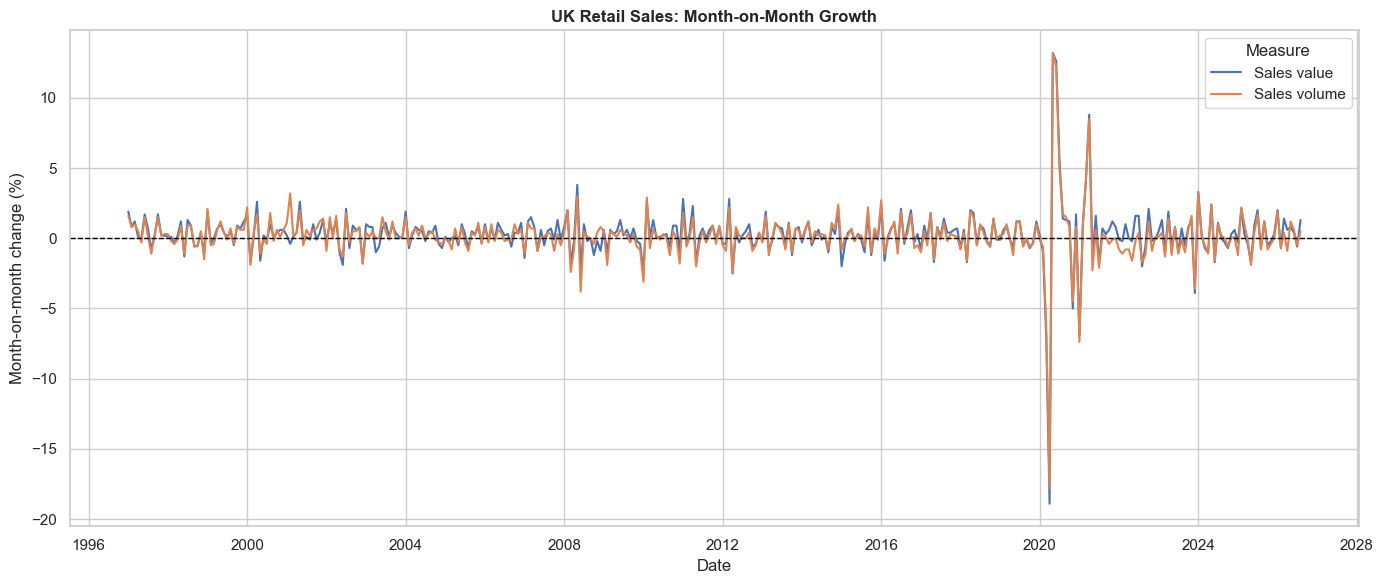

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=retail,
    x="date",
    y="value_mom_pct",
    label="Sales value",
    linewidth=1.5,
    ax=ax
)

sns.lineplot(
    data=retail,
    x="date",
    y="volume_mom_pct",
    label="Sales volume",
    linewidth=1.5,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("UK Retail Sales: Month-on-Month Growth")
ax.set_xlabel("Date")
ax.set_ylabel("Month-on-month change (%)")
ax.legend(title="Measure")

plt.tight_layout()
plt.show()

In [11]:
for column in ["value_mom_pct", "volume_mom_pct"]:
    maximum = retail.loc[retail[column].idxmax(), ["date", column]]
    minimum = retail.loc[retail[column].idxmin(), ["date", column]]

    print(f"\n{column}")
    print("Highest:", maximum["date"], maximum[column])
    print("Lowest:", minimum["date"], minimum[column])


value_mom_pct
Highest: 2020-05-01 00:00:00 13.2
Lowest: 2020-04-01 00:00:00 -18.9

volume_mom_pct
Highest: 2020-05-01 00:00:00 13.2
Lowest: 2020-04-01 00:00:00 -17.8


### Monthly-growth finding

The most severe monthly contraction occurred in April 2020, when the first national COVID-19 restrictions caused sales value to fall by 18.9% and sales volume to fall by 17.8%.

The largest monthly increase followed immediately in May 2020, with both measures rising by 13.2% as some spending recovered. However, this rebound did not fully reverse April's larger decline. These exceptional movements demonstrate why the pandemic period should be treated carefully during forecasting and model evaluation.

## 6. Relationships between retail indicators

A correlation analysis shows how strongly the five growth measures move together. Correlation ranges from −1 to +1:

- values close to +1 indicate that two measures generally move in the same direction;
- values close to −1 indicate that they generally move in opposite directions;
- values close to 0 indicate little linear relationship.

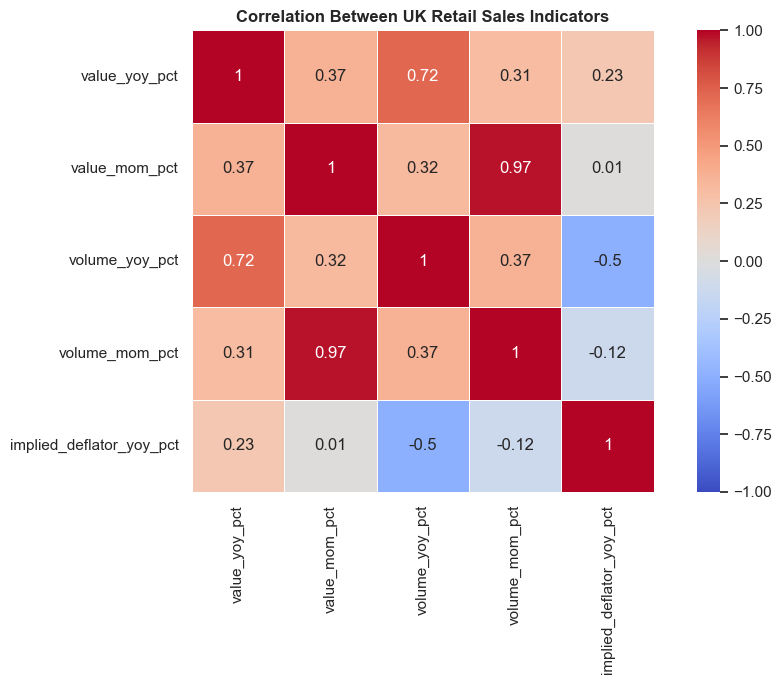

In [12]:
correlation_matrix = (
    retail.drop(columns="date")
    .corr()
    .round(2)
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Between UK Retail Sales Indicators")
plt.tight_layout()
plt.show()

### Correlation finding

Monthly sales value and volume growth have an extremely strong positive correlation of 0.97, showing that short-term movements in spending and quantities purchased usually occur together.

The annual measures also have a strong positive correlation of 0.72. However, the implied deflator has a moderate negative correlation of −0.50 with annual volume growth. This suggests that periods of stronger retail-price growth tend to coincide with weaker growth in the quantity of goods purchased.

These relationships are descriptive and should not be interpreted as proof of causation.

## 7. Comparison of major economic periods

To make the long time series easier to interpret, we compare average annual growth across four economically distinct periods:

- Pre-pandemic: 1997–2019
- COVID-19 disruption: 2020–2021
- Cost-of-living crisis: 2022–2023
- Recent period: 2024–2026

In [13]:
retail_periods = retail.copy()

retail_periods["period"] = "Pre-pandemic (1997–2019)"

retail_periods.loc[
    retail_periods["date"].between("2020-01-01", "2021-12-01"),
    "period"
] = "COVID-19 disruption (2020–2021)"

retail_periods.loc[
    retail_periods["date"].between("2022-01-01", "2023-12-01"),
    "period"
] = "Cost-of-living crisis (2022–2023)"

retail_periods.loc[
    retail_periods["date"] >= "2024-01-01",
    "period"
] = "Recent period (2024–2026)"

period_order = [
    "Pre-pandemic (1997–2019)",
    "COVID-19 disruption (2020–2021)",
    "Cost-of-living crisis (2022–2023)",
    "Recent period (2024–2026)"
]

period_summary = (
    retail_periods
    .groupby("period")[
        ["value_yoy_pct", "volume_yoy_pct", "implied_deflator_yoy_pct"]
    ]
    .mean()
    .reindex(period_order)
    .round(2)
)

period_summary

,value_yoy_pct,volume_yoy_pct,implied_deflator_yoy_pct
period,,,
Pre-pandemic (1997–2019),3.45,2.44,1.03
COVID-19 disruption (2020–2021),3.40,2.25,0.99
Cost-of-living crisis (2022–2023),4.98,-3.42,8.80
Recent period (2024–2026),2.52,0.99,1.54


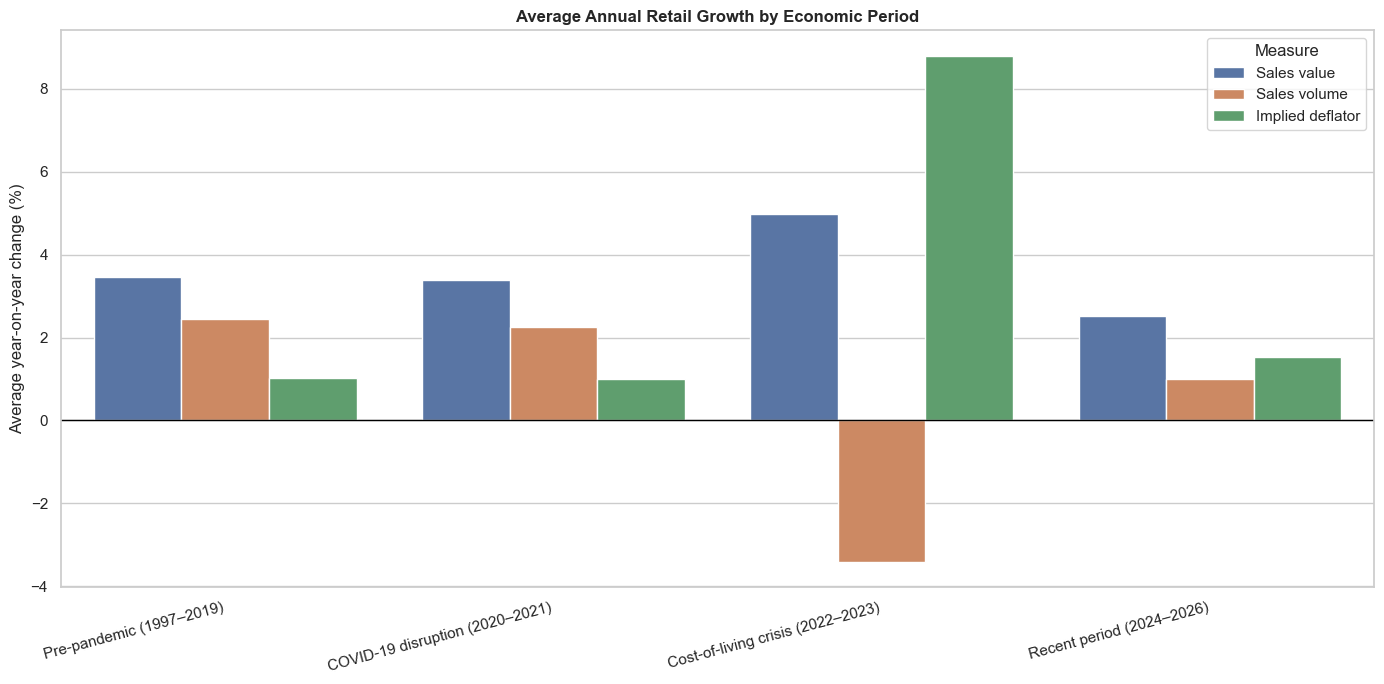

In [14]:
period_plot = (
    period_summary
    .reset_index()
    .melt(
        id_vars="period",
        var_name="measure",
        value_name="average_yoy_pct"
    )
)

measure_labels = {
    "value_yoy_pct": "Sales value",
    "volume_yoy_pct": "Sales volume",
    "implied_deflator_yoy_pct": "Implied deflator"
}

period_plot["measure"] = period_plot["measure"].map(measure_labels)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=period_plot,
    x="period",
    y="average_yoy_pct",
    hue="measure"
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Average Annual Retail Growth by Economic Period")
plt.xlabel("")
plt.ylabel("Average year-on-year change (%)")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Measure")

plt.tight_layout()
plt.show()

### Economic-period finding

Before the pandemic, retail growth was primarily supported by increasing sales volume, with comparatively modest price growth. The averages for 2020–2021 appear similar, but they conceal exceptional month-to-month volatility caused by restrictions and reopening.

The cost-of-living period presents a fundamentally different pattern. Between 2022 and 2023, sales value increased by an average of 4.98%, while sales volume declined by 3.42% and the implied deflator rose by 8.80%. Higher nominal spending therefore did not represent stronger underlying consumer demand; it was driven mainly by rising prices.

From 2024 onward, price growth moderated and sales volume returned to modest positive growth, although performance remained weaker than the pre-pandemic average.

## 8. Recent retail performance

We examine the latest 12 months separately to understand the current direction of sales value, sales volume and retail-price growth.

In [15]:
recent_12 = retail.tail(12).copy()

recent_12["date"] = recent_12["date"].dt.strftime("%b %Y")

recent_12.round(2)

,date,value_yoy_pct,value_mom_pct,volume_yoy_pct,volume_mom_pct,implied_deflator_yoy_pct
344,Sep 2025,3.6,1.2,1.8,1.2,1.7
345,Oct 2025,3.8,-0.5,1.7,-0.8,2.1
346,Nov 2025,3.2,-0.2,1.3,-0.4,1.6
347,Dec 2025,2.9,0.3,1.1,0.0,1.8
348,Jan 2026,5.3,2.0,4.3,1.9,0.9
349,Feb 2026,2.4,-0.7,1.4,-0.7,1.0
350,Mar 2026,3.6,1.4,0.9,0.4,2.8
351,Apr 2026,4.6,0.6,0.0,-0.9,4.7
352,May 2026,7.2,0.8,3.2,1.2,3.9
353,Jun 2026,6.7,0.4,3.4,0.6,3.2


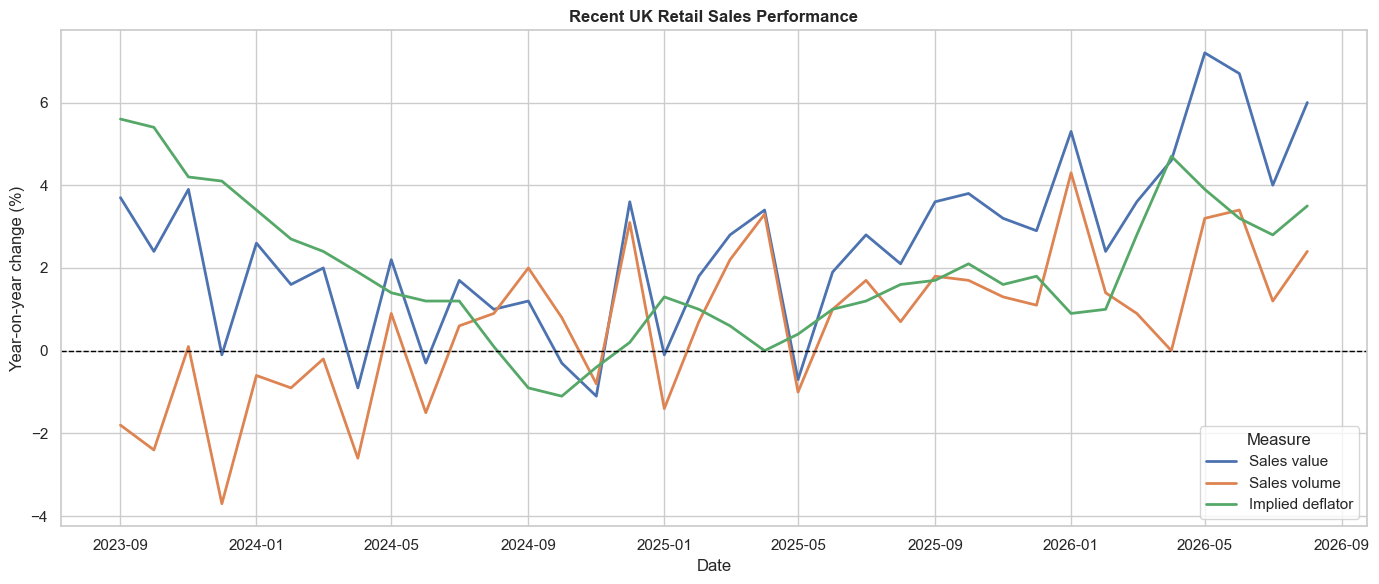

In [16]:
recent_36 = retail.tail(36)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=recent_36,
    x="date",
    y="value_yoy_pct",
    label="Sales value",
    linewidth=2,
    ax=ax
)

sns.lineplot(
    data=recent_36,
    x="date",
    y="volume_yoy_pct",
    label="Sales volume",
    linewidth=2,
    ax=ax
)

sns.lineplot(
    data=recent_36,
    x="date",
    y="implied_deflator_yoy_pct",
    label="Implied deflator",
    linewidth=2,
    ax=ax
)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Recent UK Retail Sales Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year change (%)")
ax.legend(title="Measure")

plt.tight_layout()
plt.show()

### Recent-performance finding

Recent performance indicates a recovery in underlying retail demand. Sales-volume growth was frequently negative during late 2023 and early 2024, but became more consistently positive from mid-2025 onward.

However, retail-price growth continues to make a substantial contribution to nominal spending. In August 2026, sales value was 6.0% higher than one year earlier, while volume increased by 2.4% and the implied deflator rose by 3.5%. The retail sector is therefore experiencing positive real growth, although the increase in spending remains partly price-driven.

## 9. Conclusions

This exploratory analysis produced five main findings:

1. UK retail sales value increased by an average of 3.46% per year between January 1997 and August 2026, while sales volume grew by 1.90%.
2. COVID-19 caused the most severe monthly contraction in the dataset, followed by an unusually large but incomplete rebound.
3. Retail-price growth peaked at 13.0% in July 2022.
4. During the 2022–2023 cost-of-living crisis, consumers spent more money but purchased fewer goods, demonstrating that nominal spending alone can give a misleading impression of retail performance.
5. Recent sales-volume growth has returned to positive territory, although higher prices continue to account for a substantial proportion of value growth.

The next stage of the project will examine time-series patterns and develop forecasting models for UK retail sales.